# Notebook 1 (DDS) – Data Extraction (Parsing LIN + Double-Dummy Solver)

**Tujuan:** Mengekstrak data mentah dari file LIN (Bridge Base Online) menjadi dataset terstruktur — sama seperti `notebooks/01_data_extraction.ipynb`, ditambah fitur **Double-Dummy Solver (DDS)** dari awal pipeline.

**Beda dari `notebooks/` asli:**
- Dataset akhir punya **182 fitur** (164 kanonik + 18 DDS), bukan 164.
- Output ke `data/processed_dds/`, `outputs/models_dds/`, `outputs/results_dds/` — **terpisah** dari pipeline utama, tidak menimpa `data/processed/` kanonik.
- DDS awalnya di luar ruang lingkup skripsi; disetujui masuk 2026-07-15 sebagai fitur tambahan opsional (lihat `CLAUDE.md`) setelah ditemukan bahwa akurasi model sudah mendekati batas konsistensi bidding manusia sendiri (37.6% pasangan open/closed-room BBO sepakat kontrak sama persis — lihat `experiments/2026-07-15/`).

**Output yang dihasilkan:**
- Dataset terproses (`data/processed_dds/*.csv`)
- Visualisasi distribusi dataset (`outputs/results_dds/nb01_*.png`)

**Tahap penelitian:** Tahap 1 (Data Extraction) & Tahap 2 (Parser LIN)


---
## 0. Setup

In [1]:
import sys
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

OUT = ROOT / 'outputs' / 'results_dds'
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')

print(f'ROOT : {ROOT}')
print('Setup selesai.')


ROOT : D:\Bridge-Prediction
Setup selesai.


---
## 1. Struktur File LIN

In [2]:
raw_dir = ROOT / 'data' / 'raw'
lin_files = sorted(raw_dir.glob('*.lin'))

print(f'Jumlah file LIN : {len(lin_files)}')
print(f'\nContoh nama file:')
for f in lin_files[:5]:
    print(f'  {f.name}')
print(f'  ...')
for f in lin_files[-3:]:
    print(f'  {f.name}')


Jumlah file LIN : 506

Contoh nama file:
  85168.lin
  85169.lin
  85170.lin
  85171.lin
  85173.lin
  ...
  TM-86282-1754569906.lin
  TM-90087-1754655837.lin
  TM-90210-1754657957.lin


---
## 2. Parsing File LIN

In [3]:
from src.parser import LINParser, BoardRecord

parser = LINParser()
boards = parser.parse_directory(raw_dir)

total         = len(boards)
with_contract = sum(1 for b in boards if b.contract_level is not None)
passed_out    = sum(1 for b in boards if b.contract_level is None)
complete_4x13 = sum(
    1 for b in boards
    if len(b.hands) == 4 and all(b.hands[s].total_cards() == 13 for s in 'NSEW')
)

print(f'{"="*45}')
print(f'  Total board di-parse   : {total:>6,}')
print(f'  Board dengan kontrak   : {with_contract:>6,}  ({with_contract/total*100:.1f}%)')
print(f'  Board PASS (tidak bid) : {passed_out:>6,}  ({passed_out/total*100:.1f}%)')
print(f'  Tangan lengkap (4x13)  : {complete_4x13:>6,}  ({complete_4x13/total*100:.1f}%)')
print(f'  Kontrak doubled        : {sum(1 for b in boards if b.doubled):>6,}')
print(f'  Dari {len(lin_files)} file LIN')
print(f'{"="*45}')


  Total board di-parse   : 11,236
  Board dengan kontrak   : 11,210  (99.8%)
  Board PASS (tidak bid) :     26  (0.2%)
  Tangan lengkap (4x13)  : 11,225  (99.9%)
  Kontrak doubled        :    849
  Dari 506 file LIN


In [4]:
# Tampilkan satu board secara detail
sample = next(
    b for b in boards
    if b.contract_level and b.result is not None and len(b.play) >= 10
)

print(f'Board #{sample.board_number}  |  File: {sample.source_file}  |  Room: {sample.room}')
print(f'Dealer : {sample.dealer}   Vulnerability : {sample.vulnerability}')
print()
print('Distribusi Kartu:')
for seat in ['N', 'E', 'S', 'W']:
    h = sample.hands[seat]
    line = (f'  {seat}:  '
            f'S {"-" if not h.spades else " ".join(h.spades):<13}  '
            f'H {"-" if not h.hearts else " ".join(h.hearts):<13}  '
            f'D {"-" if not h.diamonds else " ".join(h.diamonds):<13}  '
            f'C {"-" if not h.clubs else " ".join(h.clubs)}')
    print(line)

print()
print(f'Auction  : {" -> ".join(sample.auction)}')
contract = f"{sample.contract_level}{sample.contract_strain}" + ("x" if sample.doubled else "")
result_str = (f"+{sample.result}" if sample.result and sample.result > 0
              else str(sample.result) if sample.result is not None else "?")
print(f'Kontrak  : {contract} oleh {sample.declarer}  ->  Made {sample.tricks_made} trik  ({result_str})')
if sample.alerts:
    print(f'Alerts   : {sample.alerts}')


Board #13  |  File: 85168.lin  |  Room: open
Dealer : N   Vulnerability : Both

Distribusi Kartu:
  N:  S K T 8 7        H T 7 6          D 8 7 3          C 7 4 3
  E:  S Q 6 4 2        H J 5 3 2        D 2              C A Q 6 2
  S:  S J 9            H A Q 9          D Q J T 9 6      C J 9 5
  W:  S A 5 3          H K 8 4          D A K 5 4        C K T 8

Auction  : p -> p -> 1D -> 1N -> p -> 2C -> p -> 2D -> p -> 2N -> p -> 3N -> p -> p -> p
Kontrak  : 3N oleh W  ->  Made 8 trik  (-1)


---
## 3. Double-Dummy Solver (DDS)

**Konsep**: DDS menghitung jumlah trik yang bisa diambil tiap sisi di
tiap strain, dengan asumsi **permainan sempurna** dan **semua kartu
terbuka** (bukan hanya tangan sendiri seperti bidding normal). Ini
memberi jawaban teoretis "seharusnya berapa trik", terlepas dari gaya
bidding pemain. Dipakai lewat `endplay` (wrapper Python untuk DDS-nya
Bo Haglund).

**Kenapa relevan**: `experiments/2026-07-15/` menemukan bahwa dua
pasangan expert manusia yang membidik kartu **identik** (pasangan open/
closed-room BBO) hanya sepakat pada kontrak akhir yang sama persis
**37.6%** dari waktu — artinya model manapun yang hanya belajar dari
HCP/shape/fit (proxy tangan) punya batas akurasi struktural. DDS
memberi sinyal yang lebih dekat ke "jawaban seharusnya", meski tetap
tidak identik dengan apa yang benar-benar dibid manusia.

**Fitur yang dihasilkan (18 kolom)**: trik DD per strain untuk NS & EW
(10 kolom), level & strain kontrak par (6 kolom one-hot + level), sisi
yang memegang par (NS/EW), dan skor par.


In [5]:
from src.features.dds import compute_dds_features, DDS_FEATURE_COLUMNS, expand_par_denom
import pandas as pd

print(f'Fitur DDS ({len(DDS_FEATURE_COLUMNS)}): {DDS_FEATURE_COLUMNS}')
print()

# Demonstrasi pada sample board yang sama seperti di atas
dds_row = compute_dds_features(sample)
dds_row_expanded = expand_par_denom(pd.DataFrame([dds_row])).iloc[0]

print(f'Board #{sample.board_number} — DDS:')
print(f'  Trik DD NS per strain : S={dds_row["ns_dd_S"]} H={dds_row["ns_dd_H"]} '
      f'D={dds_row["ns_dd_D"]} C={dds_row["ns_dd_C"]} N={dds_row["ns_dd_N"]}')
print(f'  Trik DD EW per strain : S={dds_row["ew_dd_S"]} H={dds_row["ew_dd_H"]} '
      f'D={dds_row["ew_dd_D"]} C={dds_row["ew_dd_C"]} N={dds_row["ew_dd_N"]}')
print(f'  Kontrak par           : level {dds_row["dd_par_level"]}, '
      f'skor {dds_row["dd_par_score"]:+d}, sisi NS={bool(dds_row["dd_par_declarer_is_ns"])}')
print(f'  Kontrak aktual dibid  : {sample.contract_level}{sample.contract_strain} '
      f'oleh {sample.declarer} -> made {sample.tricks_made} trik')


Fitur DDS (18): ['ns_dd_S', 'ns_dd_H', 'ns_dd_D', 'ns_dd_C', 'ns_dd_N', 'ew_dd_S', 'ew_dd_H', 'ew_dd_D', 'ew_dd_C', 'ew_dd_N', 'dd_par_level', 'dd_par_denom_S', 'dd_par_denom_H', 'dd_par_denom_D', 'dd_par_denom_C', 'dd_par_denom_N', 'dd_par_declarer_is_ns', 'dd_par_score']



Board #13 — DDS:
  Trik DD NS per strain : S=3 H=3 D=6 C=3 N=4
  Trik DD EW per strain : S=10 H=10 D=7 C=10 N=9
  Kontrak par           : level 4, skor -620, sisi NS=False
  Kontrak aktual dibid  : 3N oleh W -> made 8 trik


---
## 4. Build Dataset (Processed CSV, dengan DDS)

> **Jalankan ulang cell ini setiap ada file LIN baru di `data/raw/`.**
>
> DDS dihitung dari cache (`experiments/2026-07-15/outputs/dds_cache.csv`,
> ~1 jam sekali hitung untuk 506 file) supaya tidak perlu dihitung ulang
> setiap rebuild. Kalau cache tidak ada, dihitung dari nol otomatis
> (lambat).


In [6]:
import shutil
from src.preprocessing import build_dataset

PROCESSED_DIR  = ROOT / 'data' / 'processed_dds'
DDS_CACHE_PATH = ROOT / 'experiments' / '2026-07-15' / 'outputs' / 'dds_cache.csv'
FORCE_REBUILD  = True   # <- set False untuk skip jika CSV sudah ada

already_built = (PROCESSED_DIR / 'train.csv').exists()

if FORCE_REBUILD or not already_built:
    if FORCE_REBUILD and already_built:
        print(f'[REBUILD] Menghapus data lama di {PROCESSED_DIR} ...')
        for f in PROCESSED_DIR.glob('*.csv'):
            f.unlink()
        for f in PROCESSED_DIR.glob('*.pkl'):
            f.unlink()
        for f in PROCESSED_DIR.glob('*.json'):
            f.unlink()

    print(f'[BUILD] Memproses {len(lin_files)} file LIN (+ DDS) ...\n')
    splits = build_dataset(
        raw_dir=ROOT / 'data' / 'raw',
        output_dir=PROCESSED_DIR,
        target_col='target_base',
        train_ratio=0.70,
        val_ratio=0.15,
        test_ratio=0.15,
        random_seed=42,
        include_dds=True,
        dds_cache_path=DDS_CACHE_PATH,
    )
    df_train_nb = splits['train']
    df_full_nb  = splits['full']
    print(f'\nDataset berhasil dibangun.')
else:
    import pandas as pd
    df_train_nb = pd.read_csv(PROCESSED_DIR / 'train.csv')
    df_full_nb  = pd.read_csv(PROCESSED_DIR / 'full.csv')
    print(f'[SKIP] Dataset sudah ada — {len(df_full_nb):,} baris. Set FORCE_REBUILD=True untuk rebuild.')

print(f'\nRingkasan:')
print(f'  File LIN diproses : {len(lin_files)}')
print(f'  Total baris       : {len(df_full_nb):,}')
print(f'  Train set         : {len(df_train_nb):,}')


[REBUILD] Menghapus data lama di D:\Bridge-Prediction\data\processed_dds ...
[BUILD] Memproses 506 file LIN (+ DDS) ...

[1/5] Parsing LIN files...


      Boards loaded: 11236
[2/5] Extracting features...


      Feature rows : 11225


[3/5] Cleaning...
      Removed 1001 duplicate rows.
      Final rows   : 10224
      No missing values in features.
[WARN] Removing 1 class(es) with <2 samples: ['5N']
[4/5] Encoding labels...
      Classes      : 35
      Classes list : ['1C', '1D', '1H', '1N', '1S', '2C', '2D', '2H', '2N', '2S', '3C', '3D', '3H', '3N', '3S', '4C', '4D', '4H', '4N', '4S', '5C', '5D', '5H', '5S', '6C', '6D', '6H', '6N', '6S', '7C', '7D', '7H', '7N', '7S', 'PASS']
      Encoder saved: D:\Bridge-Prediction\data\processed_dds\label_encoder.pkl
[DDS] Menambahkan fitur Double-Dummy Solver...
      Loading cached DDS features: D:\Bridge-Prediction\experiments\2026-07-15\outputs\dds_cache.csv


      DDS fitur ditambahkan: 18 (total fitur: 182)
[5/5] Splitting (group-aware by source_file + board_number)...


      Train : 7157
      Val   : 1533
      Test  : 1533
      No cross-split group leakage (verified).


      Saved: D:\Bridge-Prediction\data\processed_dds\train.csv
      Saved: D:\Bridge-Prediction\data\processed_dds\val.csv


      Saved: D:\Bridge-Prediction\data\processed_dds\test.csv


      Saved: D:\Bridge-Prediction\data\processed_dds\full.csv
      Feature cols saved: D:\Bridge-Prediction\data\processed_dds\feature_columns.json

Dataset berhasil dibangun.

Ringkasan:
  File LIN diproses : 506
  Total baris       : 10,223
  Train set         : 7,157


In [7]:
# Jumlah sampel per kelas untuk setiap jenis target
target_cols_info = [
    ('target_base', 'Kontrak dasar (PASS + level+strain)'),
    ('target_category', 'Kategori kontrak'),
    ('target', 'Kontrak + doubled/redoubled'),
]

for col, desc in target_cols_info:
    counts = df_full_nb[col].value_counts()
    pct = (counts / len(df_full_nb) * 100).round(2)
    print(f'{"="*55}')
    print(f'  {col}  —  {desc}')
    print(f'  {len(counts)} kelas, total {len(df_full_nb):,} sampel')
    print(f'{"="*55}')
    for cls, n in counts.items():
        print(f'  {str(cls):<8}: {n:>6,}  ({pct[cls]:.2f}%)')
    print()


  target_base  —  Kontrak dasar (PASS + level+strain)
  35 kelas, total 10,223 sampel
  3N      :  2,084  (20.39%)
  4S      :  1,585  (15.50%)
  4H      :  1,350  (13.21%)
  2S      :    569  (5.57%)
  1N      :    558  (5.46%)
  2H      :    430  (4.21%)
  3S      :    392  (3.83%)
  3H      :    389  (3.81%)
  3C      :    286  (2.80%)
  3D      :    282  (2.76%)
  5C      :    249  (2.44%)
  5D      :    244  (2.39%)
  6S      :    233  (2.28%)
  2D      :    188  (1.84%)
  5H      :    177  (1.73%)
  2N      :    164  (1.60%)
  6H      :    153  (1.50%)
  2C      :    104  (1.02%)
  5S      :    102  (1.00%)
  6D      :     95  (0.93%)
  6C      :     95  (0.93%)
  6N      :     90  (0.88%)
  4D      :     88  (0.86%)
  4C      :     87  (0.85%)
  1S      :     50  (0.49%)
  4N      :     35  (0.34%)
  1H      :     25  (0.24%)
  PASS    :     22  (0.22%)
  7S      :     22  (0.22%)
  1D      :     20  (0.20%)
  7H      :     15  (0.15%)
  7N      :     13  (0.13%)
  7D      :    

---
## 5. Statistik Dataset

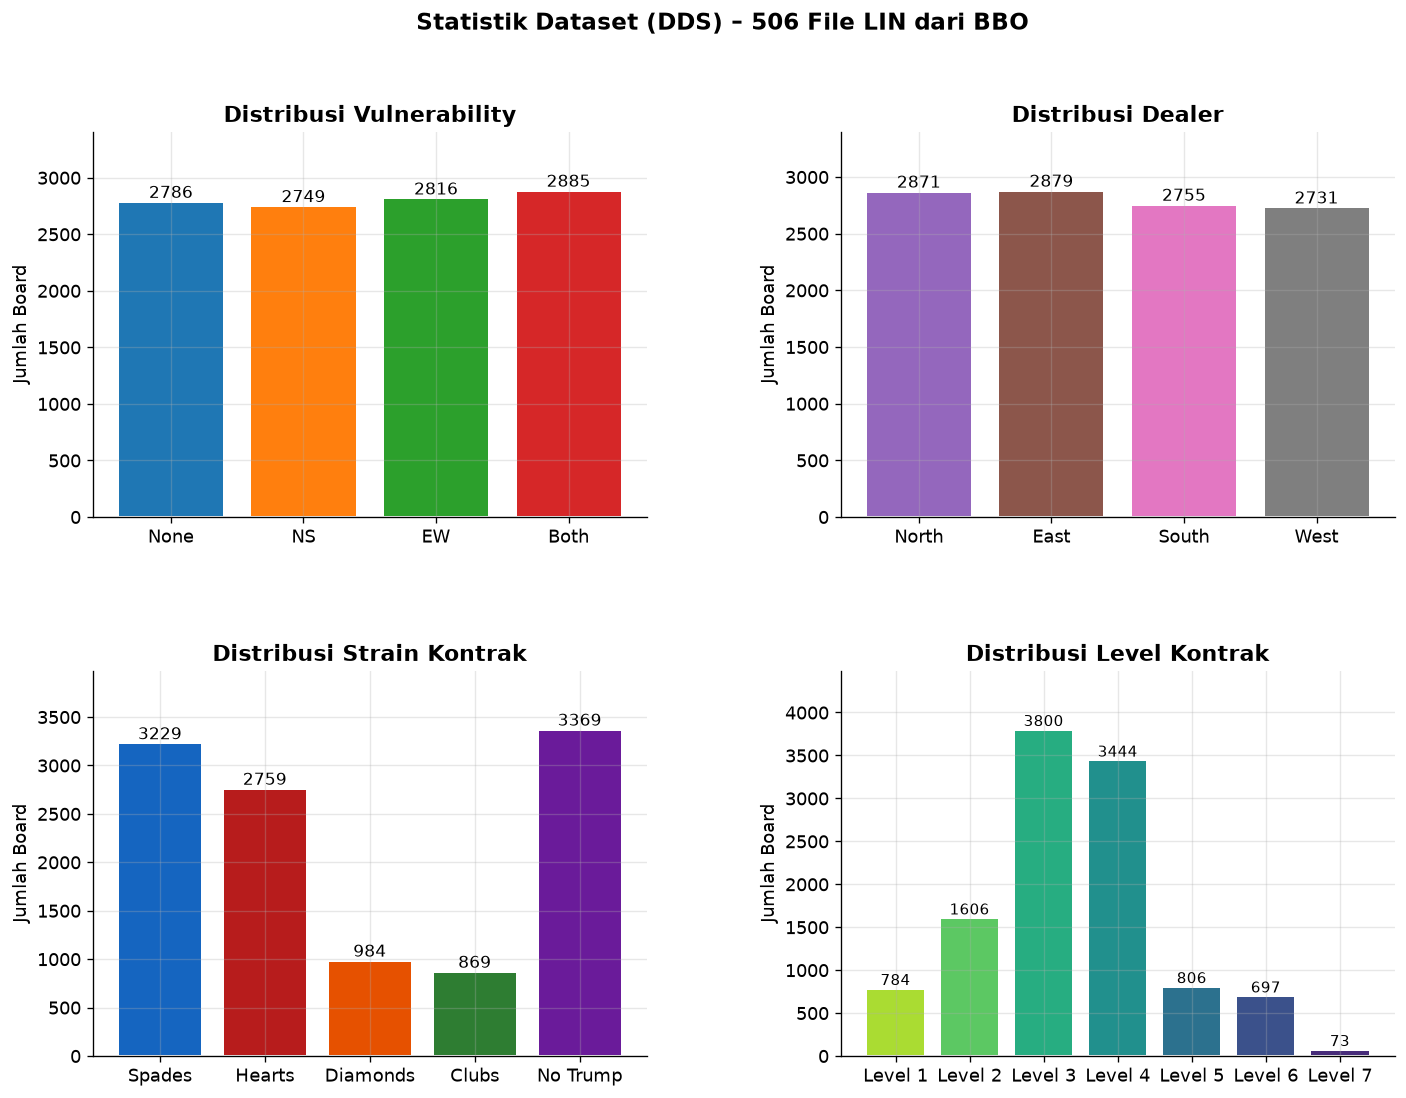

Gambar disimpan.


In [8]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

palette = sns.color_palette('tab10')

# Vulnerability
ax1 = fig.add_subplot(gs[0, 0])
vuln_order = ['None', 'NS', 'EW', 'Both']
vuln_cnt   = Counter(b.vulnerability for b in boards)
vvals      = [vuln_cnt.get(v, 0) for v in vuln_order]
bars = ax1.bar(vuln_order, vvals, color=palette[:4], edgecolor='white', linewidth=1.2)
ax1.bar_label(bars, fmt='%d', fontsize=10)
ax1.set_title('Distribusi Vulnerability', fontweight='bold')
ax1.set_ylabel('Jumlah Board')
ax1.set_ylim(0, max(vvals) * 1.18)

# Dealer
ax2 = fig.add_subplot(gs[0, 1])
dealer_cnt = Counter(b.dealer for b in boards)
dvals      = [dealer_cnt.get(s, 0) for s in ['N', 'E', 'S', 'W']]
bars = ax2.bar(['North', 'East', 'South', 'West'], dvals,
               color=palette[4:8], edgecolor='white', linewidth=1.2)
ax2.bar_label(bars, fmt='%d', fontsize=10)
ax2.set_title('Distribusi Dealer', fontweight='bold')
ax2.set_ylabel('Jumlah Board')
ax2.set_ylim(0, max(dvals) * 1.18)

# Strain
ax3 = fig.add_subplot(gs[1, 0])
strain_map_full = {'S': 'Spades', 'H': 'Hearts', 'D': 'Diamonds', 'C': 'Clubs', 'N': 'No Trump'}
strain_keys  = ['S', 'H', 'D', 'C', 'N']
strain_cnt   = Counter(b.contract_strain for b in boards if b.contract_strain)
svals        = [strain_cnt.get(k, 0) for k in strain_keys]
scols        = ['#1565C0', '#B71C1C', '#E65100', '#2E7D32', '#6A1B9A']
bars = ax3.bar([strain_map_full[k] for k in strain_keys], svals,
               color=scols, edgecolor='white', linewidth=1.2)
ax3.bar_label(bars, fmt='%d', fontsize=10)
ax3.set_title('Distribusi Strain Kontrak', fontweight='bold')
ax3.set_ylabel('Jumlah Board')
ax3.set_ylim(0, max(svals) * 1.18)

# Level
ax4 = fig.add_subplot(gs[1, 1])
level_cnt = Counter(b.contract_level for b in boards if b.contract_level)
levels    = sorted(level_cnt)
lvals     = [level_cnt[l] for l in levels]
level_lbl = [f'Level {l}' for l in levels]
lcols = sns.color_palette('viridis_r', len(levels))
bars = ax4.bar(level_lbl, lvals, color=lcols, edgecolor='white', linewidth=1.2)
ax4.bar_label(bars, fmt='%d', fontsize=9)
ax4.set_title('Distribusi Level Kontrak', fontweight='bold')
ax4.set_ylabel('Jumlah Board')
ax4.set_ylim(0, max(lvals) * 1.18)

n_lin = len(lin_files)
fig.suptitle(f'Statistik Dataset (DDS) – {n_lin} File LIN dari BBO', fontsize=14, fontweight='bold')
plt.savefig(OUT / 'nb01_dataset_stats.png', bbox_inches='tight')
plt.show()
print('Gambar disimpan.')


---
## 6. DDS vs Kontrak Aktual — Seberapa Dekat Bidding Manusia ke Par?

Bandingkan level kontrak par (DDS, teoretis optimal) dengan level
kontrak yang **benar-benar dibid** manusia — ini kuantifikasi langsung
dari "ambiguitas bidding manusia" yang jadi alasan DDS dipertimbangkan.


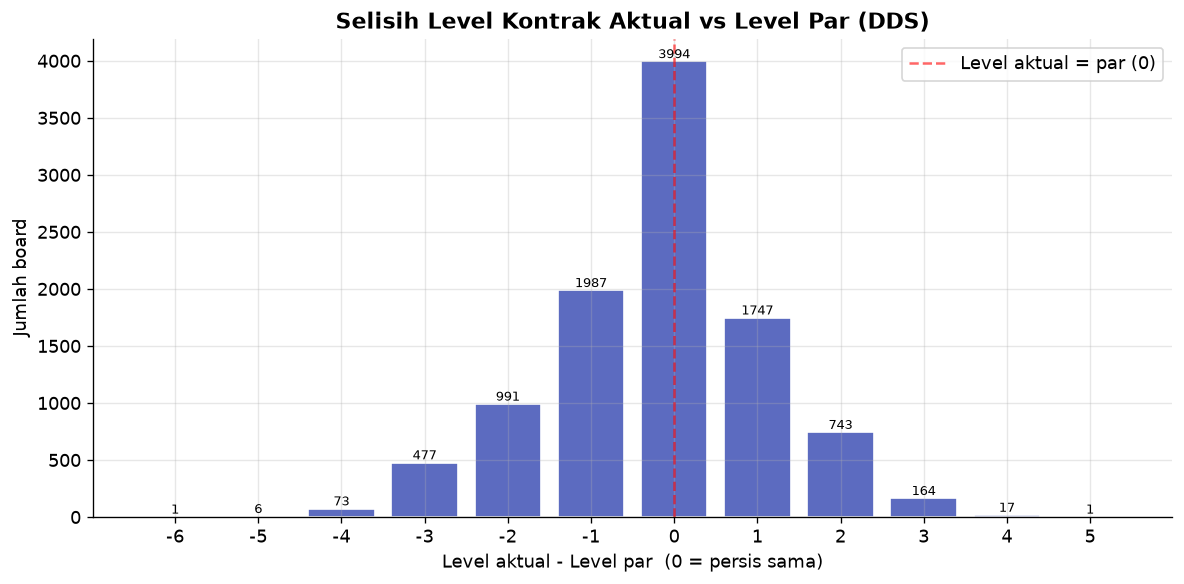

Level aktual = level par PERSIS       : 39.2%
Level aktual dalam +/-1 dari par      : 75.8%
Rata-rata (level aktual - level par)  : -0.19


In [9]:
# df_full_nb sudah punya kolom DDS langsung (dari build_dataset di atas)
actual_level = df_full_nb['target_base'].str.extract(r'^(\d)').astype(float)[0]
par_level    = df_full_nb['dd_par_level']
valid        = actual_level.notna()

diff = (actual_level[valid] - par_level[valid])

fig, ax = plt.subplots(figsize=(10, 5))
diff_cnt = diff.value_counts().sort_index()
bars = ax.bar(diff_cnt.index.astype(int).astype(str), diff_cnt.values,
              color='#5C6BC0', edgecolor='white', linewidth=1)
ax.bar_label(bars, fmt='%d', fontsize=8)
zero_pos = list(diff_cnt.index.astype(int)).index(0) if 0 in diff_cnt.index else len(diff_cnt)//2
ax.axvline(zero_pos, color='red', linestyle='--', alpha=0.6, label='Level aktual = par (0)')
ax.set_title('Selisih Level Kontrak Aktual vs Level Par (DDS)', fontweight='bold')
ax.set_xlabel('Level aktual - Level par  (0 = persis sama)')
ax.set_ylabel('Jumlah board')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'nb01_dds_vs_actual.png', bbox_inches='tight')
plt.show()

pct_exact = (diff == 0).mean() * 100
pct_within1 = (diff.abs() <= 1).mean() * 100
print(f'Level aktual = level par PERSIS       : {pct_exact:.1f}%')
print(f'Level aktual dalam +/-1 dari par      : {pct_within1:.1f}%')
print(f'Rata-rata (level aktual - level par)  : {diff.mean():+.2f}')


In [10]:

# -- Ringkasan Notebook 1 (DDS) --------------------------------------
total_boards   = len(boards)
with_contract  = sum(1 for b in boards if b.contract_level is not None)
passed_out     = total_boards - with_contract
complete_hands = sum(
    1 for b in boards
    if len(b.hands) == 4 and all(b.hands[s].total_cards() == 13 for s in 'NSEW')
)
n_full         = len(df_full_nb)
n_train        = len(df_train_nb)

from src.features import get_contract_base
from collections import Counter as _C
top3 = ', '.join(f"{k}({v:,})" for k,v in _C(
    get_contract_base(b) for b in boards if b.contract_level
).most_common(3))

print('=' * 60)
print('  RINGKASAN NOTEBOOK 1 (DDS) – Data Extraction + Double-Dummy Solver')
print('=' * 60)
print(f'  File LIN diproses     : {len(lin_files):>6,}')
print(f'  Total board di-parse  : {total_boards:>6,}')
print(f'  Board dengan kontrak  : {with_contract:>6,}  ({with_contract/total_boards*100:.1f}%)')
print(f'  Tangan lengkap (4x13) : {complete_hands:>6,}  ({complete_hands/total_boards*100:.1f}%)')
print(f'  -----------------------------------------------------')
print(f'  Dataset full (setelah dedup) : {n_full:>6,}')
print(f'  Train 70%             : {n_train:>6,}')
print(f'  Top-3 kontrak         : {top3}')
print(f'  Fitur total           : 182 (164 kanonik + 18 DDS)')
print('=' * 60)
print()
print('Lanjut ke: 02_eda_features.ipynb (DDS) -> EDA & Feature Engineering')


  RINGKASAN NOTEBOOK 1 (DDS) – Data Extraction + Double-Dummy Solver
  File LIN diproses     :    506
  Total board di-parse  : 11,236
  Board dengan kontrak  : 11,210  (99.8%)
  Tangan lengkap (4x13) : 11,225  (99.9%)
  -----------------------------------------------------
  Dataset full (setelah dedup) : 10,223
  Train 70%             :  7,157
  Top-3 kontrak         : 3N(2,360), 4S(1,743), 4H(1,481)
  Fitur total           : 182 (164 kanonik + 18 DDS)

Lanjut ke: 02_eda_features.ipynb (DDS) -> EDA & Feature Engineering
